In [1]:
%load_ext autoreload
%autoreload 2

# Calibration method comparison

In this notebook, we compare three calibration approaches on the same dataset:
1. **Raw cv2.calibrateCamera** — vanilla OpenCV with all 14 distortion coefficients, no target warp or outlier filtering
2. **Lensboy OpenCV full 14** — `OpenCVConfig` with all 14 distortion coefficients
3. **Lensboy spline 40x30** — `PinholeSplinedConfig(num_knots_x=40, num_knots_y=30)`

In [2]:
from pathlib import Path
import cv2
import numpy as np

import lensboy as lb
import lensboy.analysis as lba

## Load dataset

In [3]:
dataset_path = Path("../data/test_datasets/wide_angle_charuco.npz")
data = np.load(dataset_path)

target_points = data["target_points"]
img_h = int(data["image_height"])
img_w = int(data["image_width"])
num_frames = int(data["num_frames"])

frames = [
    lb.Frame(
        target_point_indices=data[f"frame_{i}_indices"],
        detected_points_in_image=data[f"frame_{i}_detections"],
    )
    for i in range(num_frames)
]

print(f"{num_frames} frames, {sum(len(f) for f in frames)} total detections")
print(f"Image size: {img_w} x {img_h}")

101 frames, 10424 total detections
Image size: 3088 x 2064


## Raw cv2.calibrateCamera wrapper

A thin wrapper that accepts the same inputs as `lb.calibrate_camera` but delegates to `cv2.calibrateCamera` directly. No target warp estimation, no outlier filtering.

However, to be fair to `cv2.calibrateCamera`, I will mark samples as outliers using the same criterion `lensboy` uses to filter outliers during the solve. Then they will not be counted in the statistics and plots.

In [4]:
from lensboy.calibration.calibrate import _robust_sigma_xy, DEFAULT_OUTLIER_THRESHOLD


def calibrate_camera_raw_cv2(
    target_points: np.ndarray,
    frames: list[lb.Frame],
    camera_model_config: lb.OpenCVConfig,
) -> lb.CalibrationResult[lb.OpenCV]:
    """Calibrate using raw cv2.calibrateCamera.

    Same inputs as lb.calibrate_camera, but calls cv2 directly.
    No target warp estimation or outlier filtering.
    Inlier masks are set using lensboy's outlier gating for fair comparison.

    Args:
        target_points: 3D target coordinates, shape (N, 3).
        frames: Per-image detection frames.
        camera_model_config: OpenCV model configuration.

    Returns:
        Calibration result with the same structure as lb.calibrate_camera.
    """
    # Build per-frame object/image point lists in the format cv2 expects
    object_points_list = []
    image_points_list = []
    for frame in frames:
        obj = target_points[frame.target_point_indices].astype(np.float32)
        img = frame.detected_points_in_image.astype(np.float32)
        object_points_list.append(obj)
        image_points_list.append(img)

    flags = (
        cv2.CALIB_RATIONAL_MODEL    # enables k4, k5, k6
        | cv2.CALIB_THIN_PRISM_MODEL  # enables s1, s2, s3, s4
        | cv2.CALIB_TILTED_MODEL # enables tx, ty
    )

    rms, K, dist_coeffs, rvecs, tvecs = cv2.calibrateCamera(
        object_points_list,
        image_points_list,
        (camera_model_config.image_width, camera_model_config.image_height),
        None, # type: ignore
        None, # type: ignore
        flags=flags,
    )
    print(f"cv2.calibrateCamera RMS: {rms:.4f}px")

    # First 14 coefficients match lensboy's ordering
    dist_14 = np.zeros(14, dtype=np.float64)
    dist_flat = dist_coeffs.ravel()
    n = min(len(dist_flat), 14)
    dist_14[:n] = dist_flat[:n]

    model = lb.OpenCV(
        image_width=camera_model_config.image_width,
        image_height=camera_model_config.image_height,
        fx=float(K[0, 0]),
        fy=float(K[1, 1]),
        cx=float(K[0, 2]),
        cy=float(K[1, 2]),
        distortion_coeffs=dist_14,
    )

    poses = [
        lb.Pose.from_rotvec_trans(rotvec=r.flatten(), trans=t.flatten())
        for r, t in zip(rvecs, tvecs)
    ]

    # Compute residuals per frame
    all_residuals = []
    frame_diagnostics = []
    for pose, frame in zip(poses, frames):
        pts_in_target = target_points[frame.target_point_indices]
        pts_in_cam = pose.apply(pts_in_target)
        projected = model.project_points(pts_in_cam)
        residuals = projected - frame.detected_points_in_image
        all_residuals.append(residuals)
        frame_diagnostics.append(lb.FrameDiagnostics(projected, residuals, np.ones(len(frame), dtype=bool)))

    # Apply lensboy's outlier gating so the inlier masks are comparable
    sigma = max(_robust_sigma_xy(all_residuals), 0.05)
    gate = DEFAULT_OUTLIER_THRESHOLD * sigma
    for fd in frame_diagnostics:
        fd.inlier_mask = np.linalg.norm(fd.residuals, axis=1) <= gate

    return lb.CalibrationResult(
        optimized_camera_model=model,
        optimized_cameras_T_target=poses,
        frame_diagnostics=frame_diagnostics,
    )

## Run all three calibrations

In [5]:
opencv_config = lb.OpenCVConfig(
    image_height=img_h,
    image_width=img_w,
    initial_focal_length=1000,
    included_distortion_coefficients=lb.OpenCVConfig.FULL_14,
)

In [6]:
print("=" * 60)
print("Raw cv2.calibrateCamera")
print("=" * 60)
raw_cv2_result = calibrate_camera_raw_cv2(
    target_points, frames, camera_model_config=opencv_config,
)

Raw cv2.calibrateCamera
cv2.calibrateCamera RMS: 0.3044px


In [7]:
print("=" * 60)
print("Lensboy OpenCV full 14")
print("=" * 60)

opencv_result = lb.calibrate_camera(
    target_points, frames, camera_model_config=opencv_config,
)

Lensboy OpenCV full 14
Computing initial poses with PnP...
Running full optimization...
Ran optimizer in 0.64s
Outlier filtering: 90/10424 (0.9%) outliers - going again...
Running full optimization...
Ran optimizer in 0.39s
Outlier filtering: 116/10424 (1.1%) outliers - going again...
Running full optimization...
Ran optimizer in 0.12s
Target warp max deflection: 0.4683 (target units)
Residuals (inliers): mean=0.138px, worst=0.543px


In [8]:
print("=" * 60)
print("Lensboy spline 40x30")
print("=" * 60)
spline_result = lb.calibrate_camera(
    target_points,
    frames,
    camera_model_config=lb.PinholeSplinedConfig(
        img_h, img_w,
        initial_focal_length=1000,
        num_knots_x=40,
        num_knots_y=30,
    ),
)

Lensboy spline 40x30
Calibrating seed opencv model...
Computing initial poses with PnP...
Running full optimization...
Ran optimizer in 0.41s
Residuals (inliers): mean=0.235px, worst=5.170px
OpenCV seed model ready in 0.5s
Computed FOV from OpenCV model: 141.8° x 124.2°
Calculating matching spline model...
Matching spline model ready in 1.5s
Running full optimization...
Performed full optimization in 9.57s
Outlier filtering: 113/10424 (1.1%) outliers - going again...
Running full optimization...
Performed full optimization in 17.03s
Outlier filtering: 148/10424 (1.4%) outliers - going again...
Running full optimization...
Performed full optimization in 8.57s
Target warp max deflection: 0.4726 (target units)
Residuals (inliers): mean=0.109px, worst=0.492px


## Residual histograms
With all models ready, let's look at the residual histograms. 

## Summary statistics

In [9]:
results = {
    "Raw cv2.calibrateCamera": raw_cv2_result,
    "Lensboy OpenCV full 14": opencv_result,
    "Lensboy spline 40x30": spline_result,
}

for name, r in results.items():
    sigma = r.residual_sigma_map()
    n_out = r.num_outliers()
    n_det = r.num_detections()
    inlier_norms = np.concatenate([
        np.linalg.norm(fi.residuals[fi.inlier_mask], axis=1)
        for fi in r.frame_diagnostics if fi.inlier_mask.any()
    ])
    print(
        f"{name:30s}  "
        f"sigma={sigma:.4f}px  "
        f"mean={np.mean(inlier_norms):.4f}px  "
        f"worst={np.max(inlier_norms):.4f}px  "
        f"outliers={n_out}/{n_det} ({n_out/n_det*100:.1f}%)"
    )

Raw cv2.calibrateCamera         sigma=0.1688px  mean=0.2251px  worst=0.8505px  outliers=89/10424 (0.9%)
Lensboy OpenCV full 14          sigma=0.1034px  mean=0.1380px  worst=0.5431px  outliers=116/10424 (1.1%)
Lensboy spline 40x30            sigma=0.0794px  mean=0.1094px  worst=0.4921px  outliers=148/10424 (1.4%)


We clearly obtain better solves with lensboy. The lensboy opencv model is way better than raw `cv2.calibrateCamera`, and the spline model is even better.

# Residual plots
Let's now look at the residual plot for each model

In [10]:
axis_range = 0.7

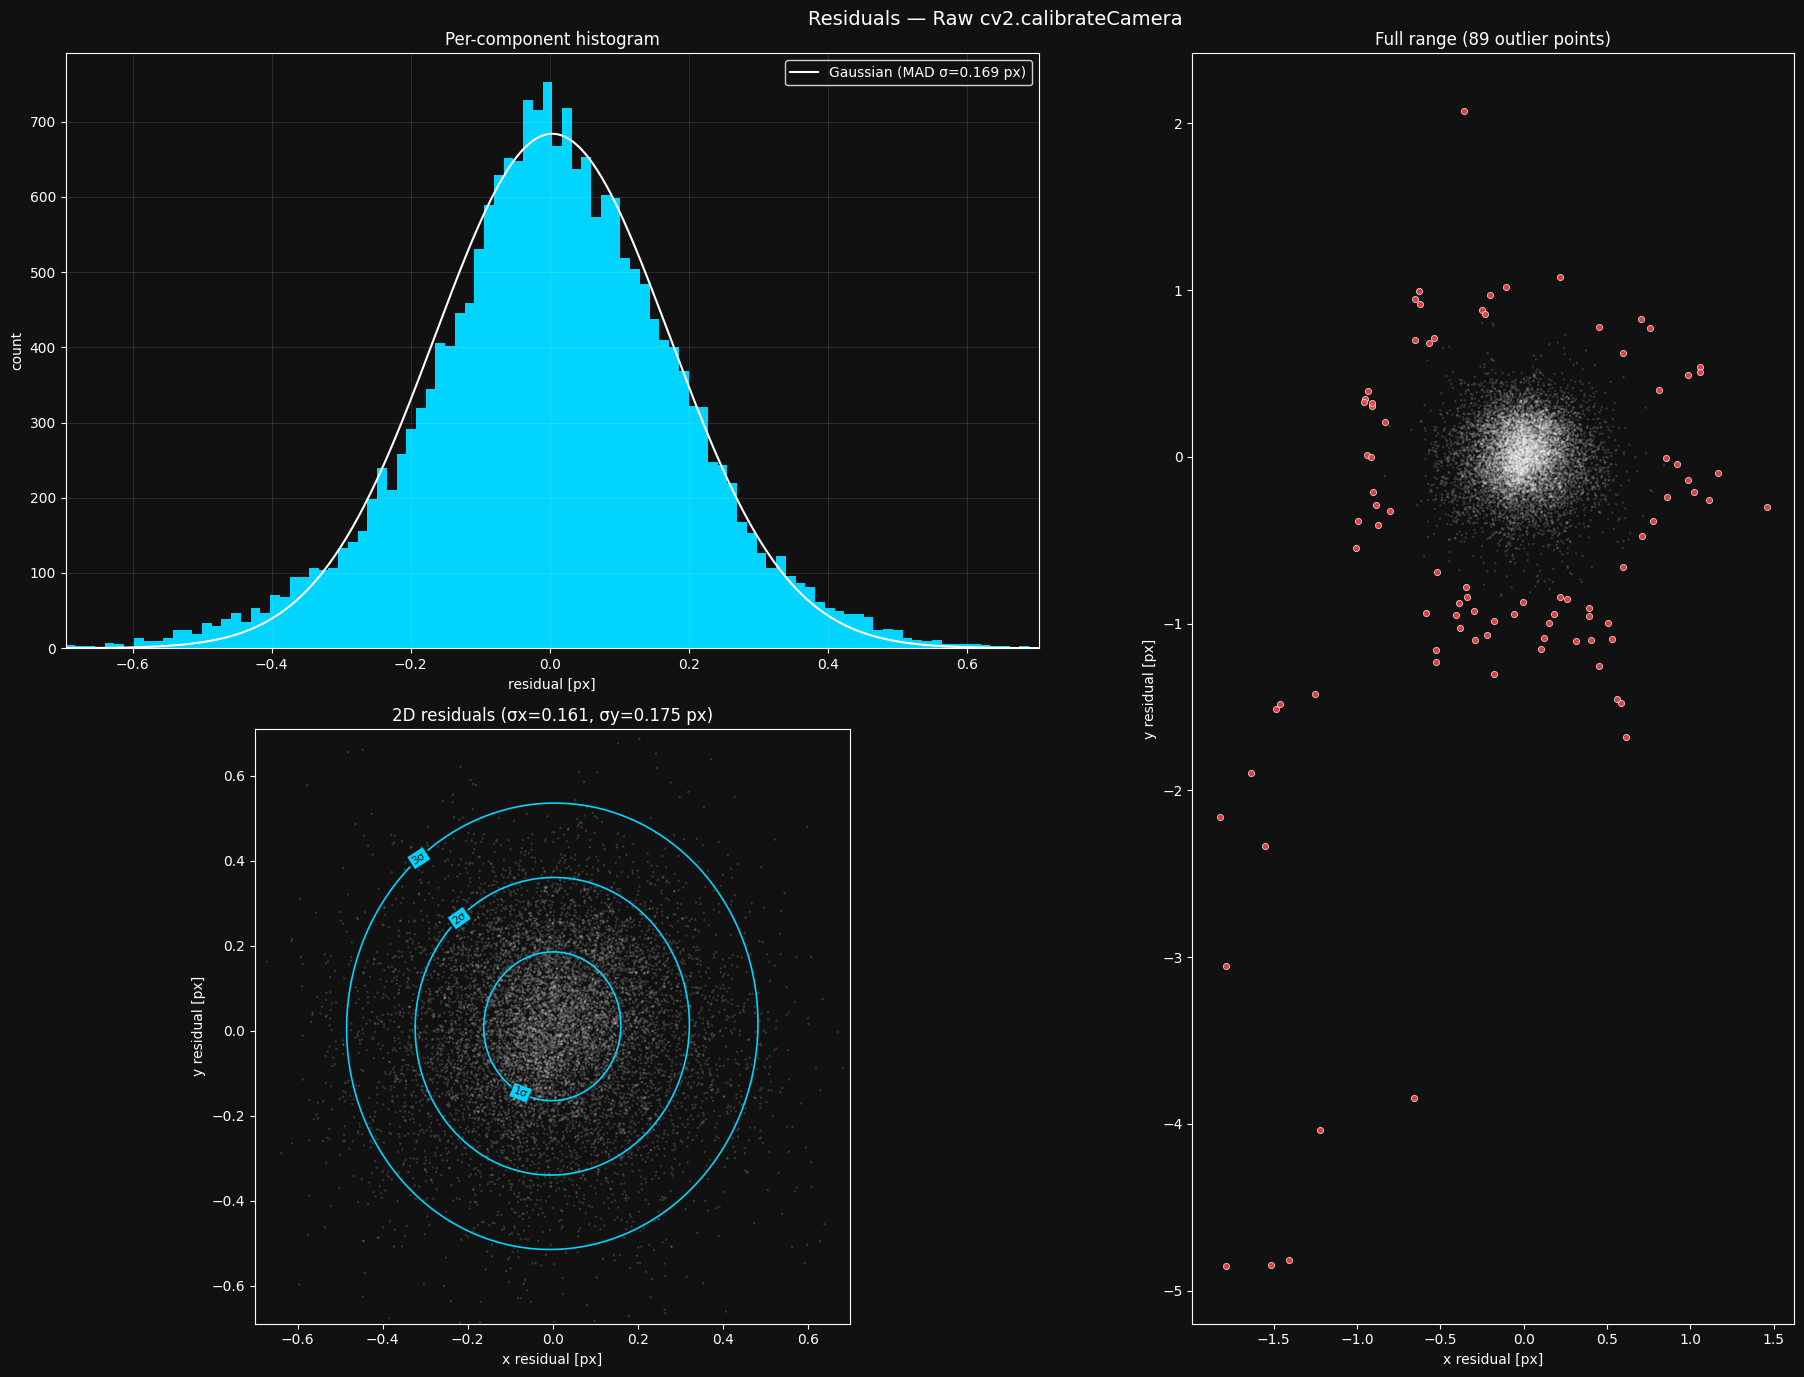

In [11]:
lba.plot_residuals(
    raw_cv2_result.frame_diagnostics, 
    title="Residuals — Raw cv2.calibrateCamera", 
    axis_range=axis_range
)

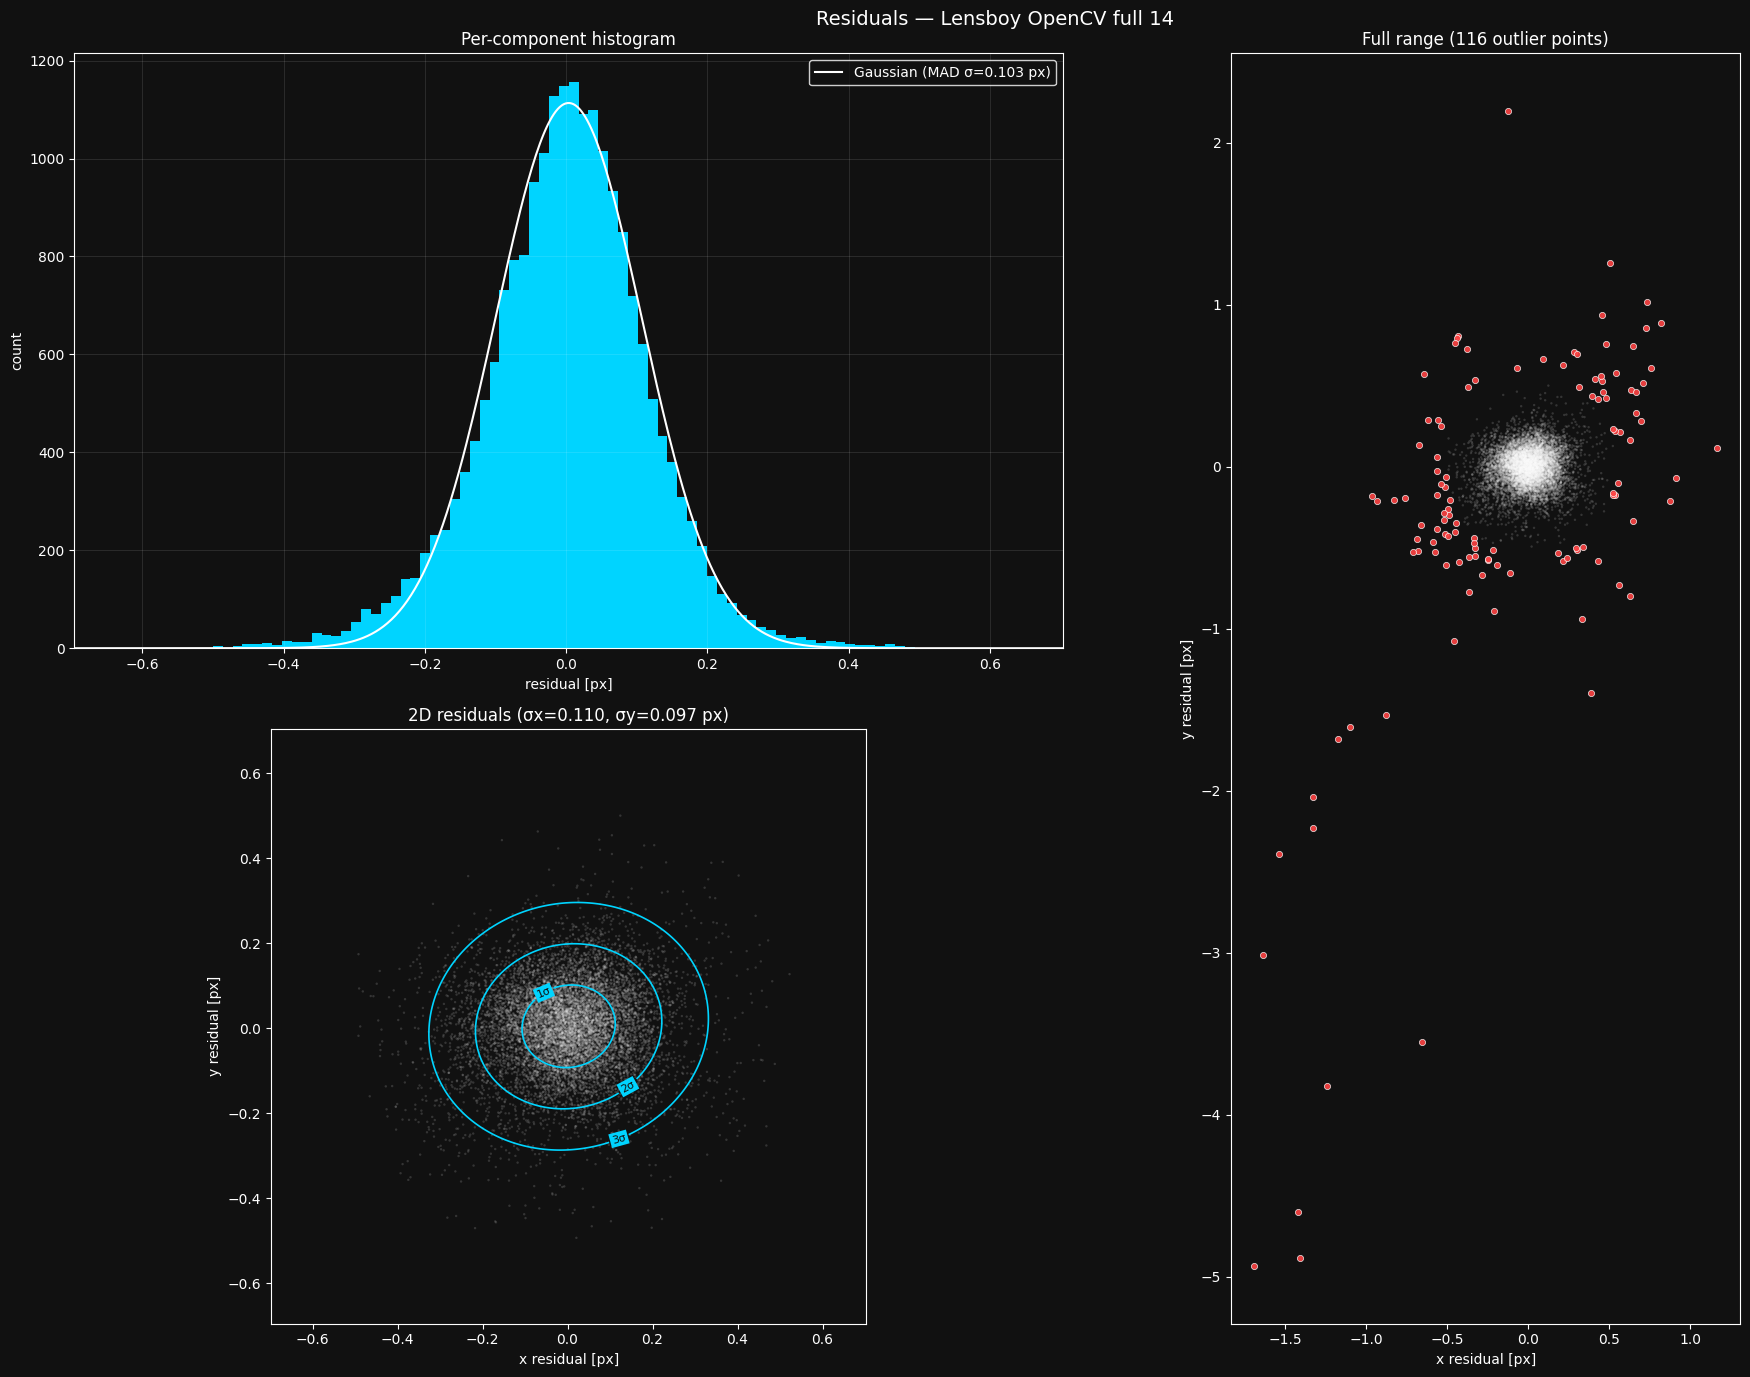

In [12]:
lba.plot_residuals(
    opencv_result.frame_diagnostics, 
    title="Residuals — Lensboy OpenCV full 14", 
    axis_range=axis_range
)

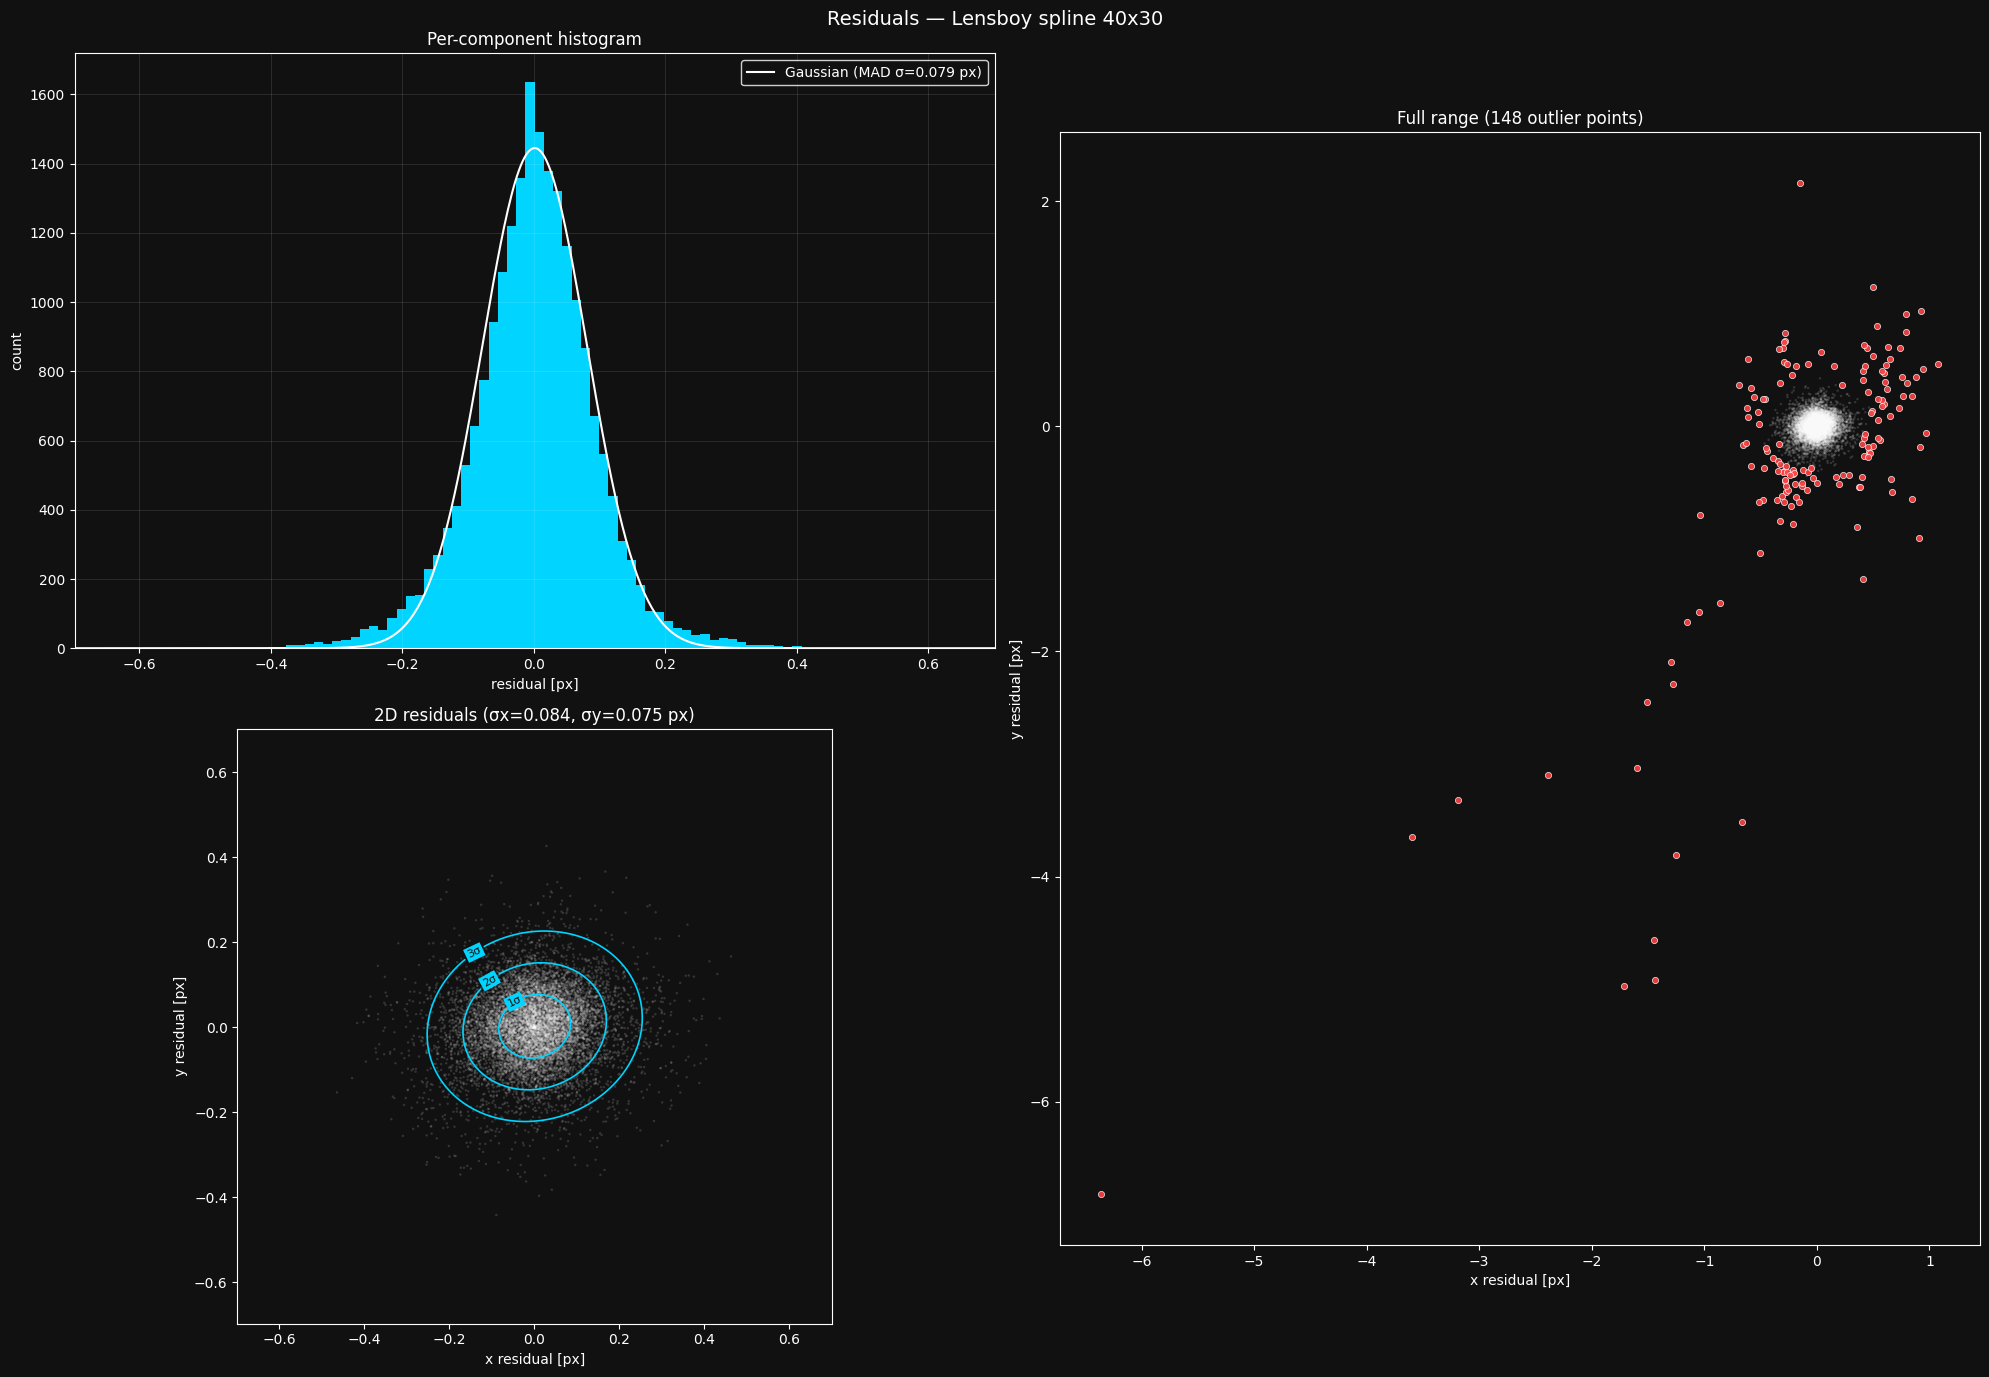

In [13]:
lba.plot_residuals(
    spline_result.frame_diagnostics, 
    title="Residuals — Lensboy spline 40x30", 
    axis_range=axis_range
)

I think these results speak for themselves. We clearly see that the `lensboy` calibrated opencv model is a way better fit.
And the spline model is even better.

## Residual grids
Now let's check whether we see systematic patterns in the residuals.

In [14]:
heatmap_max = 1.0

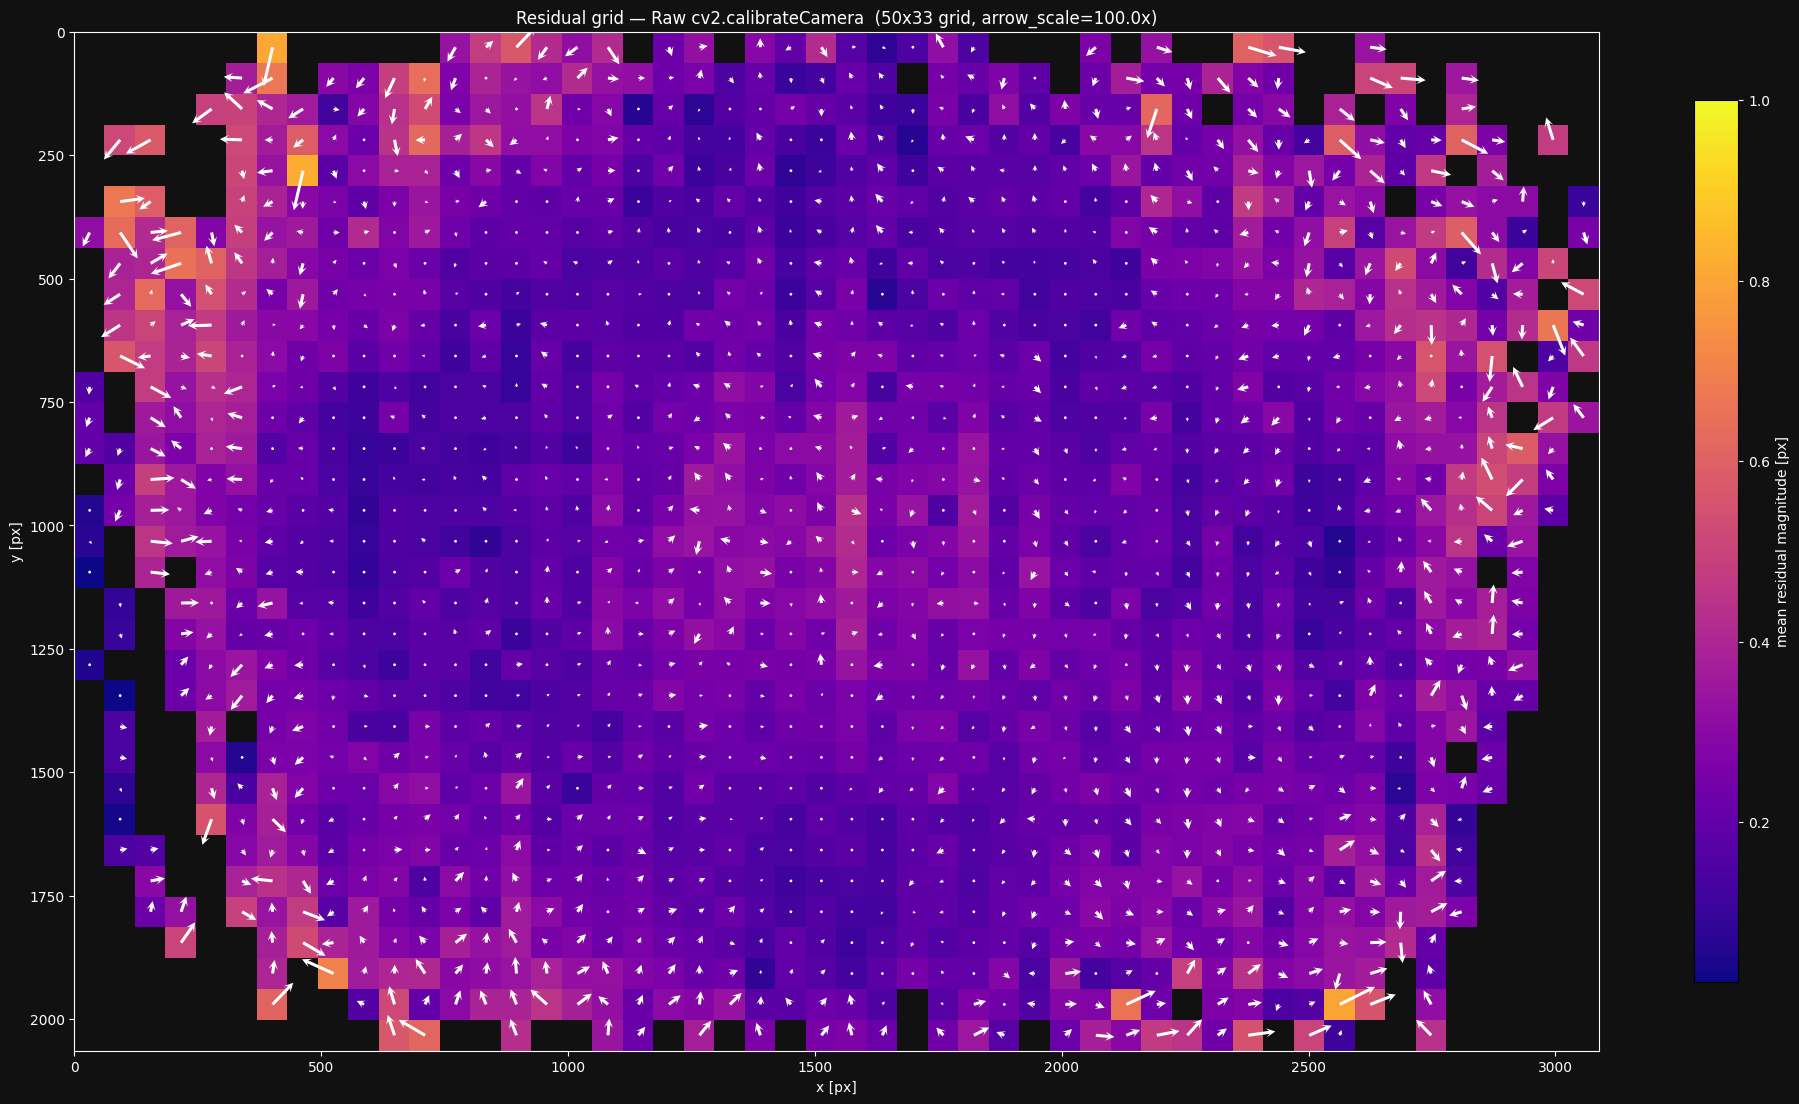

In [15]:
lba.plot_residual_grid(
    frames, raw_cv2_result.frame_diagnostics,
    image_width=img_w, image_height=img_h,
    grid_cells=50, title="Residual grid — Raw cv2.calibrateCamera",
    heatmap_max=heatmap_max
)

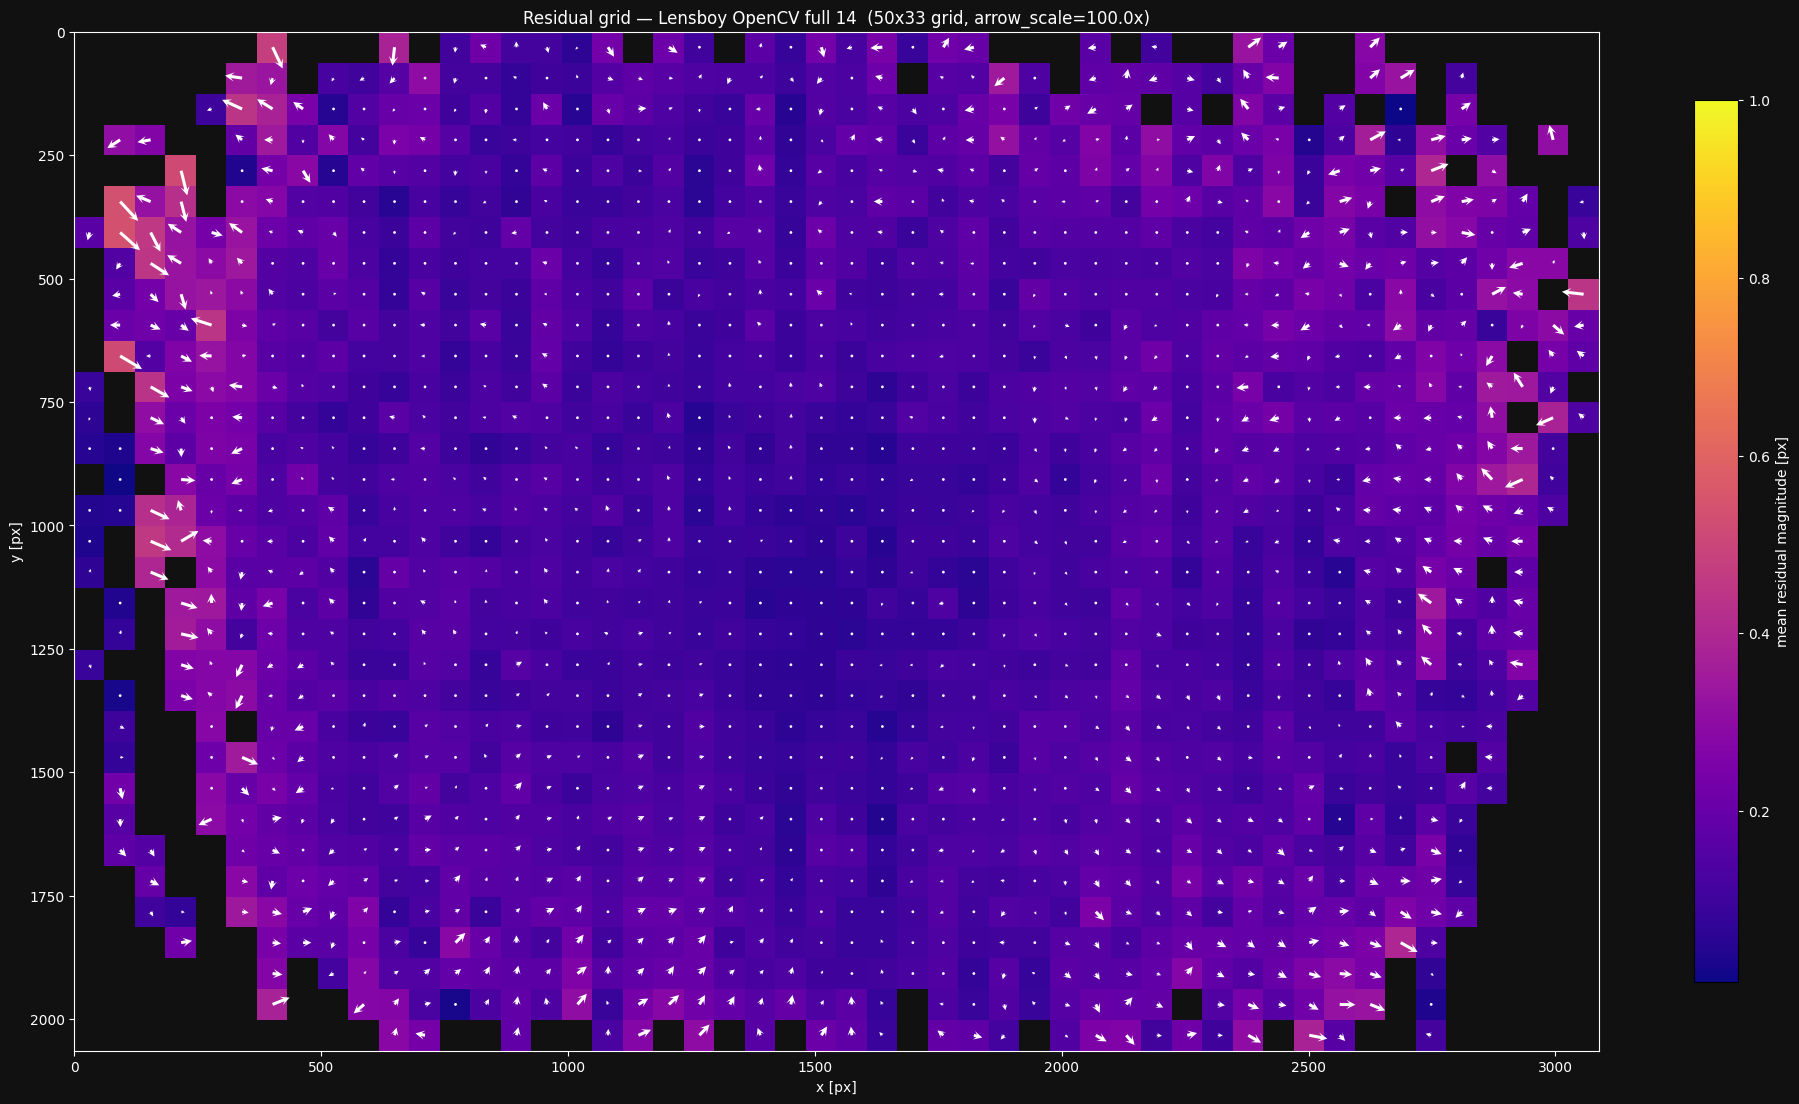

In [16]:
lba.plot_residual_grid(
    frames, opencv_result.frame_diagnostics,
    image_width=img_w, image_height=img_h,
    grid_cells=50, title="Residual grid — Lensboy OpenCV full 14",
    heatmap_max=heatmap_max
)

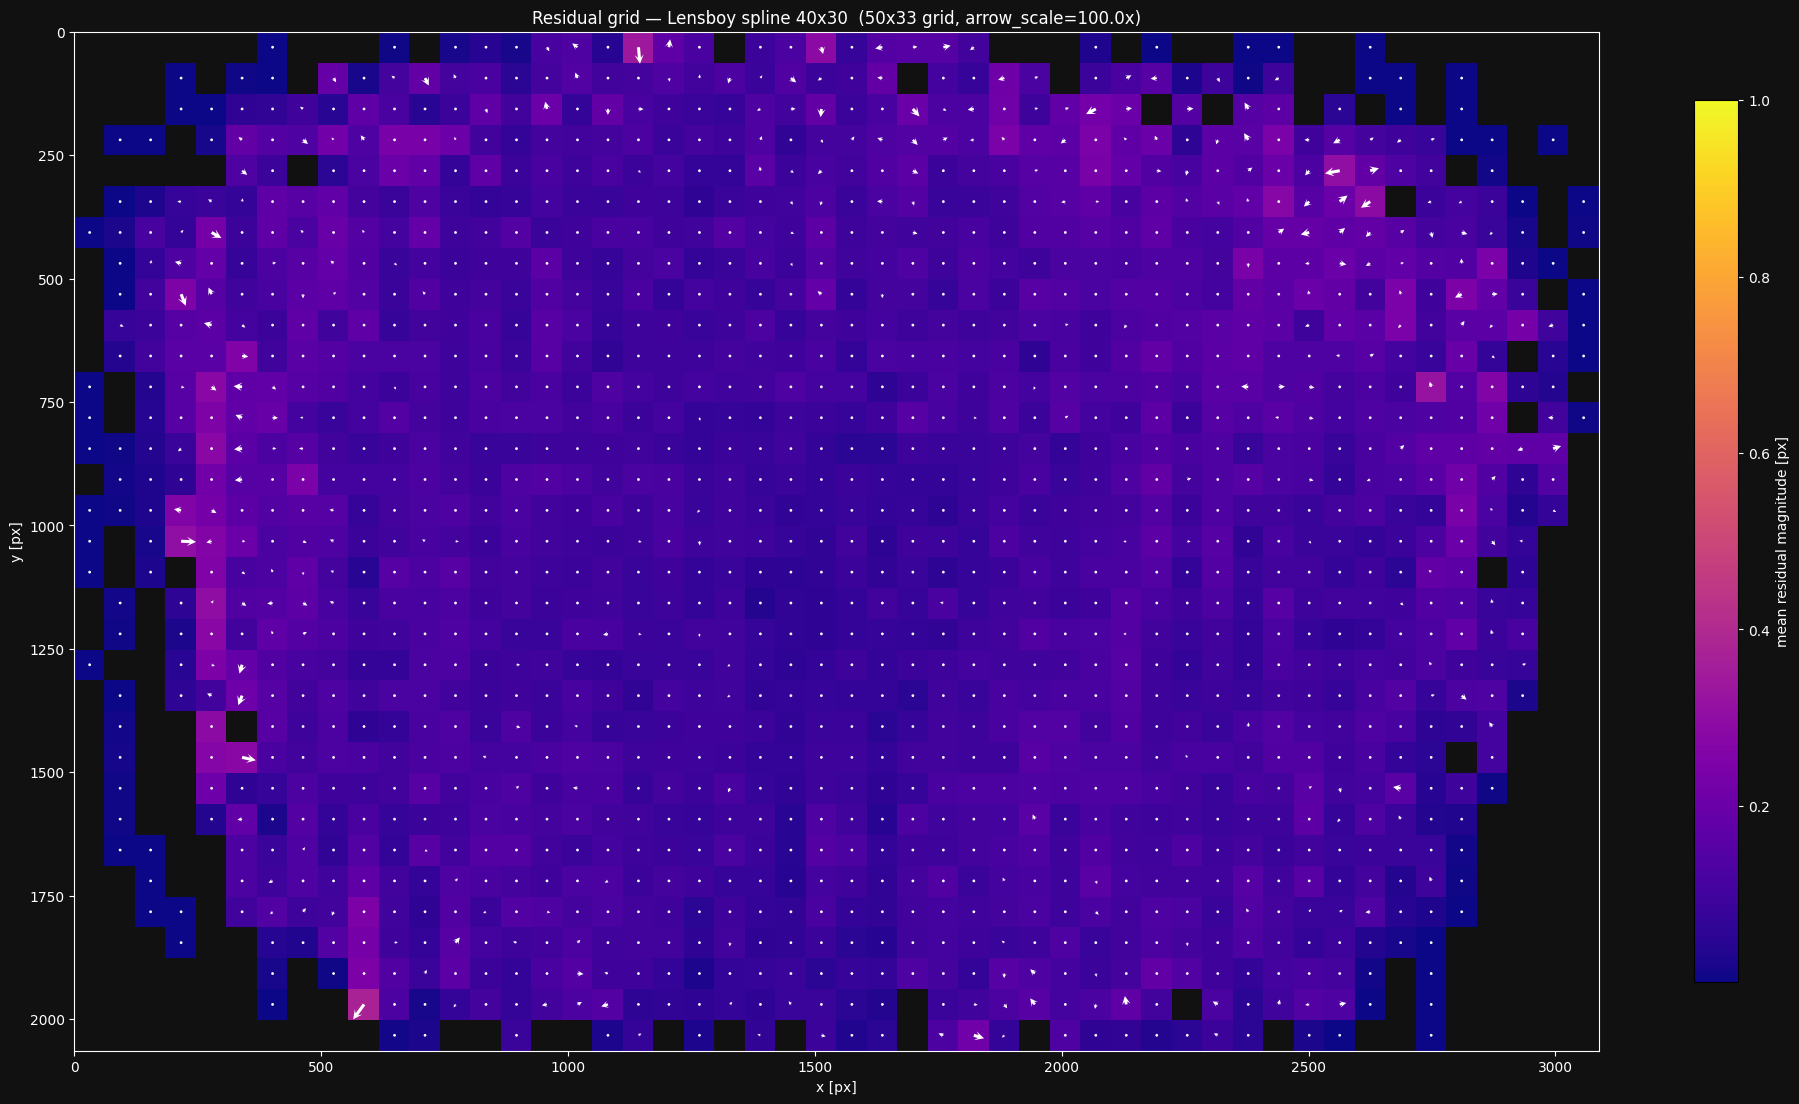

In [17]:
lba.plot_residual_grid(
    frames, spline_result.frame_diagnostics,
    image_width=img_w, image_height=img_h,
    grid_cells=50, title="Residual grid — Lensboy spline 40x30",
    heatmap_max=heatmap_max
)

Again, results speak for themselves. The raw opencv model is far worse fit than the lensboy opencv model, and the splined model is even better.